In [1]:
# import necessary libraries
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# define paths (update with your paths)
base_dir = r"S:\chexpert\raw_data"
train_csv = os.path.join(base_dir, "train_cheXbert.csv")

# load CSV files
train_df = pd.read_csv(train_csv)

# display first few rows of the training DataFrame
print("Training Data:")
train_df.head()


Training Data:


,Path,Sex,Age,Frontal/Lateral,AP/PA,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,No Finding
0,CheXpert-v1.0/train/patient00001/study1/view1_...,Female,68,Frontal,AP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0,1.0
1,CheXpert-v1.0/train/patient00002/study2/view1_...,Female,87,Frontal,AP,NaN,1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN,NaN
2,CheXpert-v1.0/train/patient00002/study1/view1_...,Female,83,Frontal,AP,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
3,CheXpert-v1.0/train/patient00002/study1/view2_...,Female,83,Lateral,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
4,CheXpert-v1.0/train/patient00003/study1/view1_...,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN


In [2]:
print("Columns in Training Data:", train_df.columns)

Columns in Training Data: Index(['Path', 'Sex', 'Age', 'Frontal/Lateral', 'AP/PA',
       'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity',
       'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis',
       'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture',
       'Support Devices', 'No Finding'],
      dtype='object')


In [3]:
# define conditions dynamically by excluding non-pathology columns
non_pathology_columns = ['Path', 'Sex', 'Age', 'Frontal/Lateral', 'AP/PA']
conditions = [col for col in train_df.columns if col not in non_pathology_columns]

print("Conditions:", conditions)

Conditions: ['Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices', 'No Finding']


In [4]:
print("Missing Values in Training Data:")
print(train_df.isnull().sum())

Missing Values in Training Data:
Path                               0
Sex                                0
Age                                0
Frontal/Lateral                    0
AP/PA                          32387
Enlarged Cardiomediastinum    178223
Cardiomegaly                  172776
Lung Opacity                  114911
Lung Lesion                   211146
Edema                         136902
Consolidation                 151520
Pneumonia                     195858
Atelectasis                   154406
Pneumothorax                  144447
Pleural Effusion               90188
Pleural Other                 216586
Fracture                      210274
Support Devices               106137
No Finding                    202290
dtype: int64


In [5]:
# new subset of training data without lateral and PA views
sub_train_df = train_df[train_df['Frontal/Lateral'] == 'Frontal']
sub_train_df = train_df[train_df['AP/PA'] == 'AP']

# display first few rows of the training DataFrame
print("Training Data:")
sub_train_df.head()


Training Data:


,Path,Sex,Age,Frontal/Lateral,AP/PA,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,No Finding
0,CheXpert-v1.0/train/patient00001/study1/view1_...,Female,68,Frontal,AP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0,1.0
1,CheXpert-v1.0/train/patient00002/study2/view1_...,Female,87,Frontal,AP,NaN,1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN,NaN
2,CheXpert-v1.0/train/patient00002/study1/view1_...,Female,83,Frontal,AP,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
4,CheXpert-v1.0/train/patient00003/study1/view1_...,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
9,CheXpert-v1.0/train/patient00005/study2/view1_...,Male,33,Frontal,AP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN


In [6]:
#total number of images
total_images = len(train_df)
print("Total Images:", total_images)

Total Images: 223414


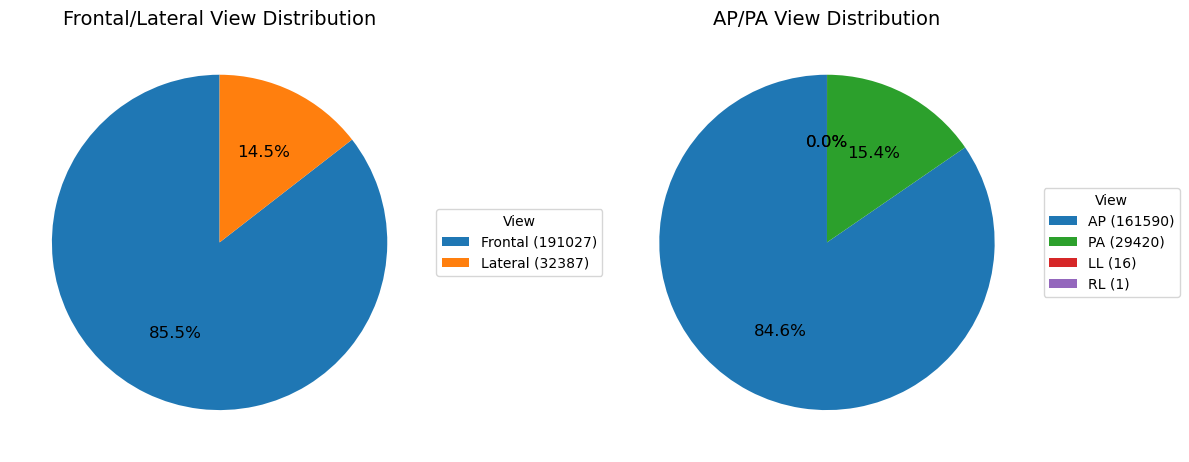

In [7]:
import matplotlib.pyplot as plt

# colors
colors1 = ['#1f77b4', '#ff7f0e']           # frontal/lateral
colors2 = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd']  # AP/PA (excluding "0")

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# --- frontal/lateral view distribution ---
fl_counts = train_df["Frontal/Lateral"].value_counts()
wedges_fl, texts_fl, autotexts_fl = ax[0].pie(
    fl_counts.values,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors1,
    textprops={'fontsize': 12}
)
ax[0].set_title('Frontal/Lateral View Distribution', fontsize=14)
ax[0].set_ylabel("")

# build custom legend labels: "category (count)"
legend_labels_fl = [f"{label} ({count})" for label, count in zip(fl_counts.index, fl_counts)]
ax[0].legend(
    wedges_fl, legend_labels_fl, title="View", 
    loc="center left", bbox_to_anchor=(1, 0, 0.5, 1)
)

# --- AP/PA view distribution (excluding "0" by filtering only frontal views) ---
ap_pa_counts = train_df[train_df["Frontal/Lateral"] == "Frontal"]["AP/PA"].value_counts()
wedges_ap_pa, texts_ap_pa, autotexts_ap_pa = ax[1].pie(
    ap_pa_counts.values,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors2,
    textprops={'fontsize': 12}
)
ax[1].set_title('AP/PA View Distribution', fontsize=14)
ax[1].set_ylabel("")

# build custom legend labels for AP/PA
legend_labels_ap_pa = [f"{label} ({count})" for label, count in zip(ap_pa_counts.index, ap_pa_counts)]
ax[1].legend(
    wedges_ap_pa, legend_labels_ap_pa, title="View", 
    loc="center left", bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.tight_layout()
plt.show()

C:\Users\johnt\AppData\Local\Temp\ipykernel_5876\4286923415.py:29: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ap_pa_counts = sub_train_df[train_df["Frontal/Lateral"] == "Frontal"]["AP/PA"].value_counts()


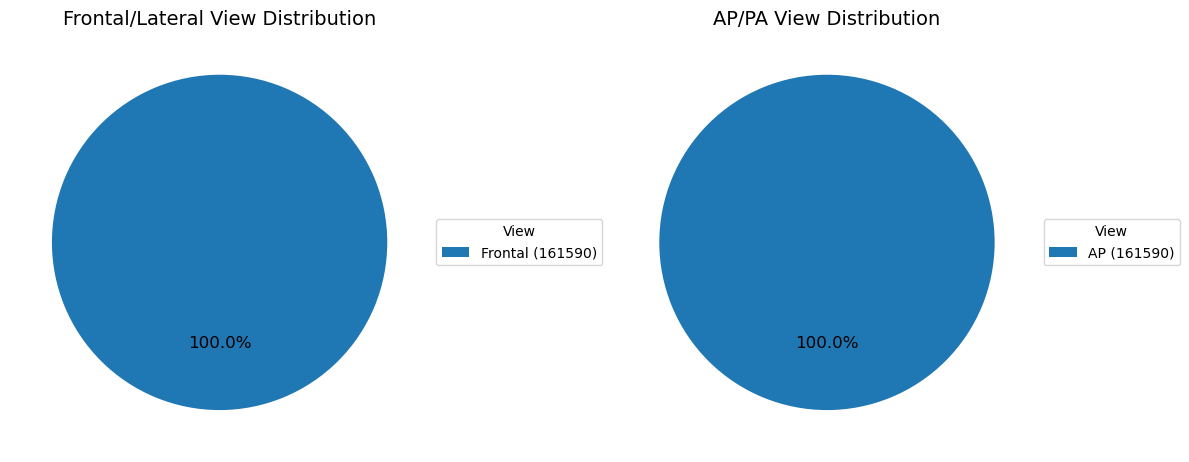

In [8]:
import matplotlib.pyplot as plt

# colors
colors1 = ['#1f77b4', '#ff7f0e']           # frontal/lateral
colors2 = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd']  # AP/PA (excluding "0")

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# --- frontal/lateral view distribution ---
fl_counts = sub_train_df["Frontal/Lateral"].value_counts()
wedges_fl, texts_fl, autotexts_fl = ax[0].pie(
    fl_counts.values,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors1,
    textprops={'fontsize': 12}
)
ax[0].set_title('Frontal/Lateral View Distribution', fontsize=14)
ax[0].set_ylabel("")

# build custom legend labels: "category (count)"
legend_labels_fl = [f"{label} ({count})" for label, count in zip(fl_counts.index, fl_counts)]
ax[0].legend(
    wedges_fl, legend_labels_fl, title="View", 
    loc="center left", bbox_to_anchor=(1, 0, 0.5, 1)
)

# --- AP/PA view distribution (excluding "0" by filtering only frontal views) ---
ap_pa_counts = sub_train_df[train_df["Frontal/Lateral"] == "Frontal"]["AP/PA"].value_counts()
wedges_ap_pa, texts_ap_pa, autotexts_ap_pa = ax[1].pie(
    ap_pa_counts.values,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors2,
    textprops={'fontsize': 12}
)
ax[1].set_title('AP/PA View Distribution', fontsize=14)
ax[1].set_ylabel("")

# build custom legend labels for AP/PA
legend_labels_ap_pa = [f"{label} ({count})" for label, count in zip(ap_pa_counts.index, ap_pa_counts)]
ax[1].legend(
    wedges_ap_pa, legend_labels_ap_pa, title="View", 
    loc="center left", bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.tight_layout()
plt.show()

Label Counts in Training Data:
                            Negative (0)  Positive (1)  Uncertain (-1)  \
Enlarged Cardiomediastinum       22527.0        7611.0         15053.0   
Cardiomegaly                     16155.0       30566.0          3917.0   
Lung Opacity                      5096.0      103092.0           315.0   
Lung Lesion                       1349.0        9346.0          1573.0   
Edema                            21243.0       53058.0         12211.0   
Consolidation                    31523.0       13682.0         26689.0   
Pneumonia                         3314.0        4856.0         19386.0   
Atelectasis                        730.0       33862.0         34416.0   
Pneumothorax                     58663.0       17869.0          2435.0   
Pleural Effusion                 36278.0       89314.0          7634.0   
Pleural Other                      138.0        3959.0          2731.0   
Fracture                          3937.0        8701.0           502.0   
Support

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13]),
 [Text(0, 0, 'Enlarged Cardiomediastinum'),
  Text(1, 0, 'Cardiomegaly'),
  Text(2, 0, 'Lung Opacity'),
  Text(3, 0, 'Lung Lesion'),
  Text(4, 0, 'Edema'),
  Text(5, 0, 'Consolidation'),
  Text(6, 0, 'Pneumonia'),
  Text(7, 0, 'Atelectasis'),
  Text(8, 0, 'Pneumothorax'),
  Text(9, 0, 'Pleural Effusion'),
  Text(10, 0, 'Pleural Other'),
  Text(11, 0, 'Fracture'),
  Text(12, 0, 'Support Devices'),
  Text(13, 0, 'No Finding')])

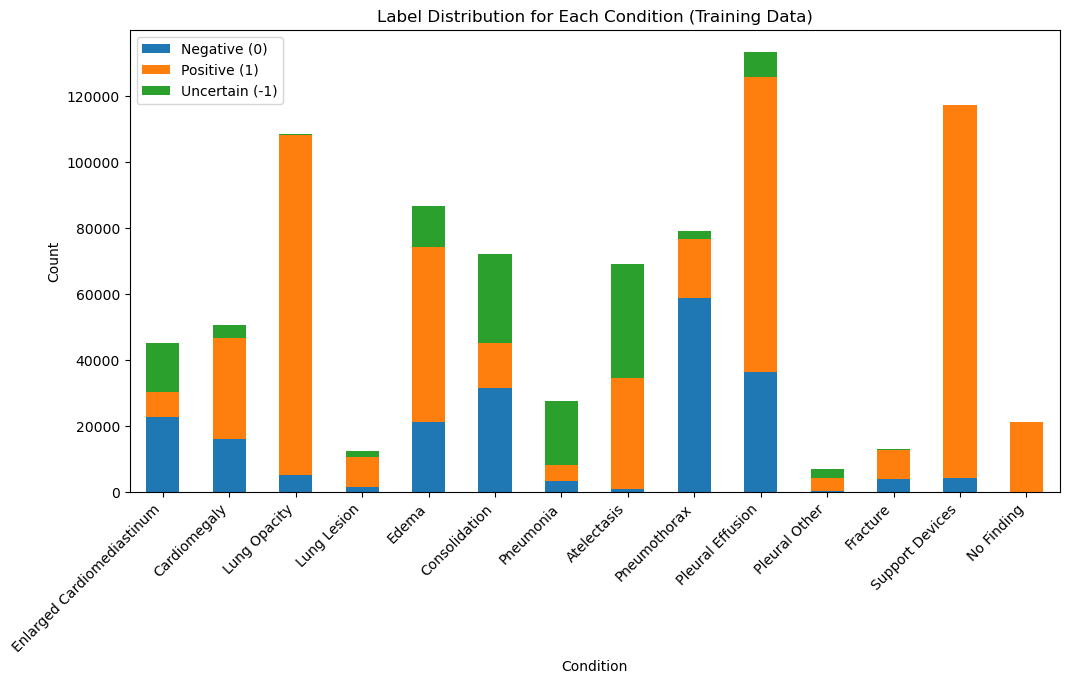

In [9]:
# count occurrences of each label value and reindex to include all possible categories
label_counts = train_df[conditions].apply(pd.Series.value_counts).T
label_counts = label_counts.reindex(columns=[0, 1, -1, np.nan])
label_counts.columns = ["Negative (0)", "Positive (1)", "Uncertain (-1)", "Unmentioned (NaN)"]

# display counts
print("Label Counts in Training Data:")
print(label_counts)

# plot label distribution
label_counts.drop(columns="Unmentioned (NaN)").plot(kind="bar", figsize=(12, 6), stacked=True)
plt.title("Label Distribution for Each Condition (Training Data)")
plt.ylabel("Count")
plt.xticks(
    ticks=range(len(label_counts.index)),  # set ticks to match bar positions
    labels=label_counts.index,            # set labels to condition names
    rotation=45,                          # rotate for better readability
    ha="right"                            # align labels to right for better clarity
)
plt.xlabel("Condition")
plt.legend(loc="upper left")
plt.xticks(rotation=45)

Label Counts in Training Data:
                            Negative (0)  Positive (1)  Uncertain (-1)  \
Enlarged Cardiomediastinum        9761.0        5457.0         10679.0   
Cardiomegaly                      6840.0       22896.0          2881.0   
Lung Opacity                      2858.0       83340.0           158.0   
Lung Lesion                        222.0        4953.0           860.0   
Edema                            11748.0       48850.0         10376.0   
Consolidation                    13306.0       10931.0         21400.0   
Pneumonia                         1053.0        2792.0         14329.0   
Atelectasis                        344.0       26945.0         27150.0   
Pneumothorax                     41007.0       14598.0          2060.0   
Pleural Effusion                 15837.0       71388.0          5201.0   
Pleural Other                       42.0        1652.0          1084.0   
Fracture                          2191.0        5826.0           291.0   
Support

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13]),
 [Text(0, 0, 'Enlarged Cardiomediastinum'),
  Text(1, 0, 'Cardiomegaly'),
  Text(2, 0, 'Lung Opacity'),
  Text(3, 0, 'Lung Lesion'),
  Text(4, 0, 'Edema'),
  Text(5, 0, 'Consolidation'),
  Text(6, 0, 'Pneumonia'),
  Text(7, 0, 'Atelectasis'),
  Text(8, 0, 'Pneumothorax'),
  Text(9, 0, 'Pleural Effusion'),
  Text(10, 0, 'Pleural Other'),
  Text(11, 0, 'Fracture'),
  Text(12, 0, 'Support Devices'),
  Text(13, 0, 'No Finding')])

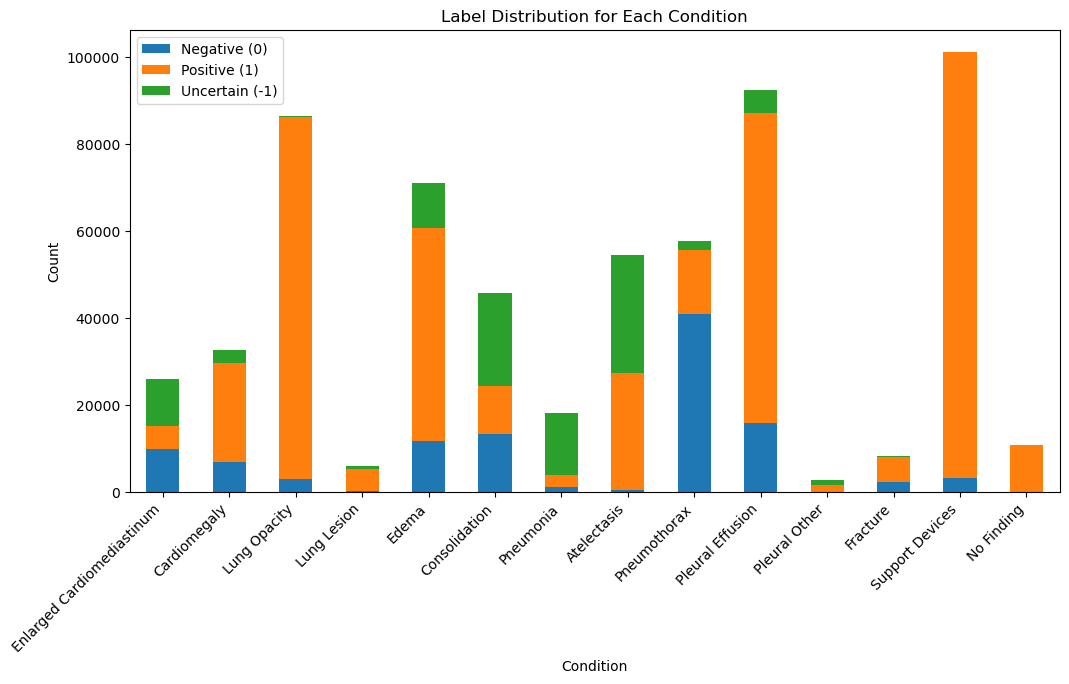

In [10]:
# label distribution for subset of training data
label_counts = sub_train_df[conditions].apply(pd.Series.value_counts).T
label_counts = label_counts.reindex(columns=[0, 1, -1, np.nan]) 
label_counts.columns = ["Negative (0)", "Positive (1)", "Uncertain (-1)", "Unmentioned (NaN)"]

# display counts
print("Label Counts in Training Data:")
print(label_counts)

# plot label distribution
label_counts.drop(columns="Unmentioned (NaN)").plot(kind="bar", figsize=(12, 6), stacked=True)
plt.title("Label Distribution for Each Condition")
plt.ylabel("Count")
plt.xticks(
    ticks=range(len(label_counts.index)),  # set ticks to match bar positions
    labels=label_counts.index,            # set labels to condition names
    rotation=45,                          # rotate for better readability
    ha="right"                            # align labels to right for better clarity
)
plt.xlabel("Condition")
plt.xticks(rotation=45)

In [11]:
# subset of training data where N/A values are replaced with 0
sub_train_df.fillna(0, inplace=True)

C:\Users\johnt\AppData\Local\Temp\ipykernel_5876\717220722.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_train_df.fillna(0, inplace=True)


In [12]:
print("Missing Values in Training Data:")
print(sub_train_df.isnull().sum())

Missing Values in Training Data:
Path                          0
Sex                           0
Age                           0
Frontal/Lateral               0
AP/PA                         0
Enlarged Cardiomediastinum    0
Cardiomegaly                  0
Lung Opacity                  0
Lung Lesion                   0
Edema                         0
Consolidation                 0
Pneumonia                     0
Atelectasis                   0
Pneumothorax                  0
Pleural Effusion              0
Pleural Other                 0
Fracture                      0
Support Devices               0
No Finding                    0
dtype: int64


Label Counts in Training Data:
                            Negative (0)  Positive (1)  Uncertain (-1)  \
Enlarged Cardiomediastinum      145454.0        5457.0         10679.0   
Cardiomegaly                    135813.0       22896.0          2881.0   
Lung Opacity                     78092.0       83340.0           158.0   
Lung Lesion                     155777.0        4953.0           860.0   
Edema                           102364.0       48850.0         10376.0   
Consolidation                   129259.0       10931.0         21400.0   
Pneumonia                       144469.0        2792.0         14329.0   
Atelectasis                     107495.0       26945.0         27150.0   
Pneumothorax                    144932.0       14598.0          2060.0   
Pleural Effusion                 85001.0       71388.0          5201.0   
Pleural Other                   158854.0        1652.0          1084.0   
Fracture                        155473.0        5826.0           291.0   
Support

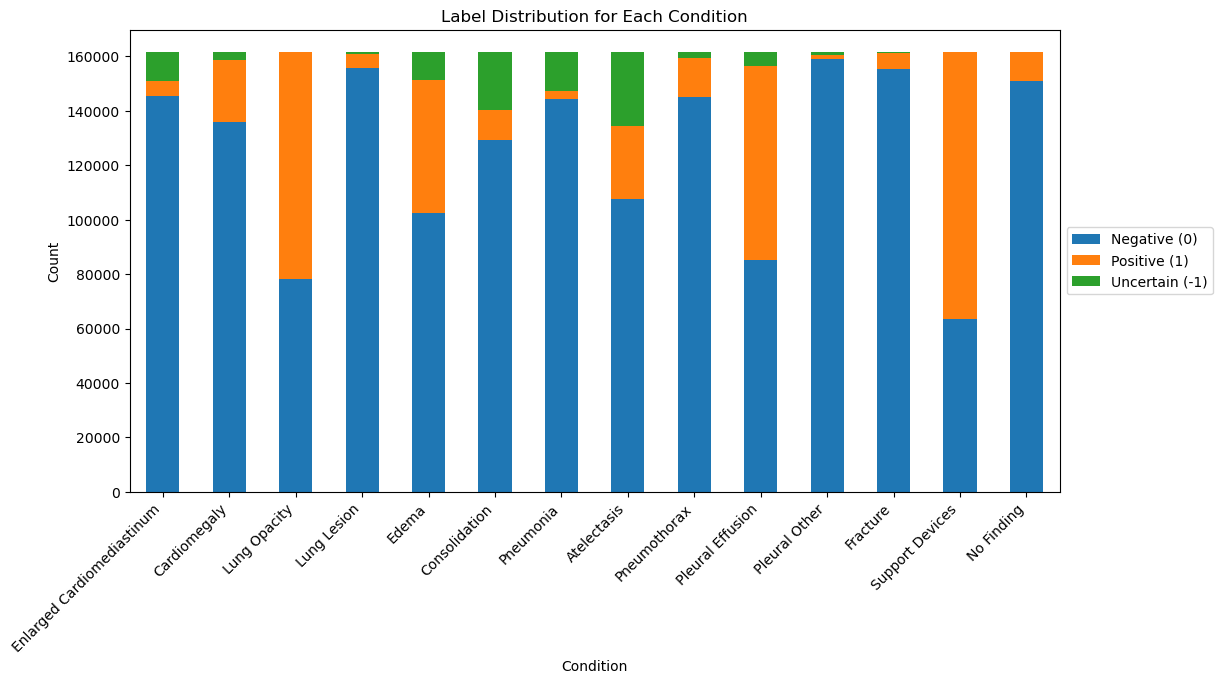

In [13]:
# label distribution for subset of training data
label_counts = sub_train_df[conditions].apply(pd.Series.value_counts).T
label_counts = label_counts.reindex(columns=[0, 1, -1, np.nan]) 
label_counts.columns = ["Negative (0)", "Positive (1)", "Uncertain (-1)", "Unmentioned (NaN)"]

# display counts
print("Label Counts in Training Data:")
print(label_counts)

# plot label distribution
label_counts.drop(columns="Unmentioned (NaN)").plot(kind="bar", figsize=(12, 6), stacked=True)
plt.title("Label Distribution for Each Condition")
plt.ylabel("Count")
plt.xticks(
    ticks=range(len(label_counts.index)),  # set ticks to match bar positions
    labels=label_counts.index,            # set labels to condition names
    rotation=45,                          # rotate for better readability
    ha="right"                            # align labels to right for better clarity
)
plt.xlabel("Condition")
plt.xticks(rotation=45)

# legend outside the plot
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

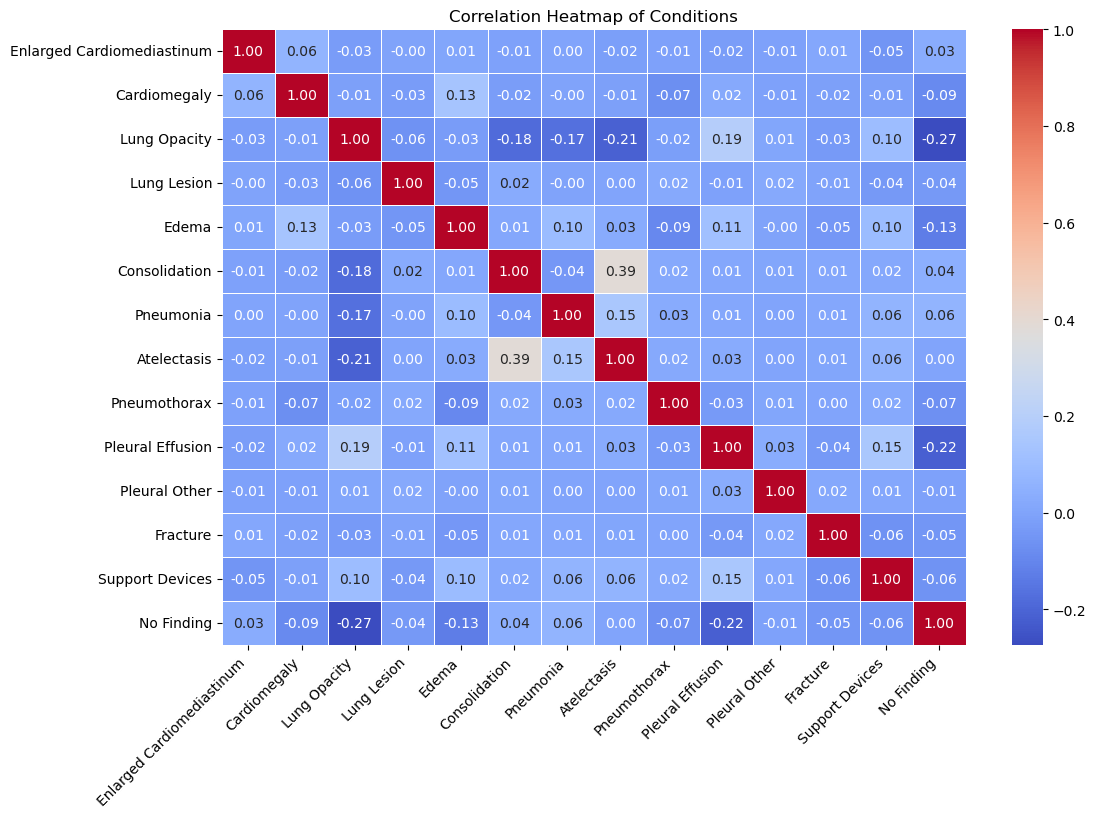

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# compute correlation matrix
correlation_matrix = sub_train_df[conditions].corr(method='spearman')

# plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, linewidths=0.5)
plt.title("Correlation Heatmap of Conditions")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

In [15]:
# correlation values for the subset of training data in descending order
correlation_values = correlation_matrix.unstack().sort_values(ascending=False)
correlation_values = correlation_values[correlation_values != 1]  # exclude self-correlations

# display top 10 most positively and negatively correlated pairs in dataframe
print("Top 20 Most Positively Correlated Pairs:")
correlation_df = pd.DataFrame(correlation_values, columns=["Correlation"])
correlation_df.head(20)


Top 20 Most Positively Correlated Pairs:


,,Correlation
Atelectasis,Consolidation,0.387104
Consolidation,Atelectasis,0.387104
Pleural Effusion,Lung Opacity,0.190834
Lung Opacity,Pleural Effusion,0.190834
Support Devices,Pleural Effusion,0.152969
Pleural Effusion,Support Devices,0.152969
Atelectasis,Pneumonia,0.149331
Pneumonia,Atelectasis,0.149331
Cardiomegaly,Edema,0.134712
Edema,Cardiomegaly,0.134712


Sex Distribution:
Sex
Male       132636
Female      90777
Unknown         1
Name: count, dtype: int64


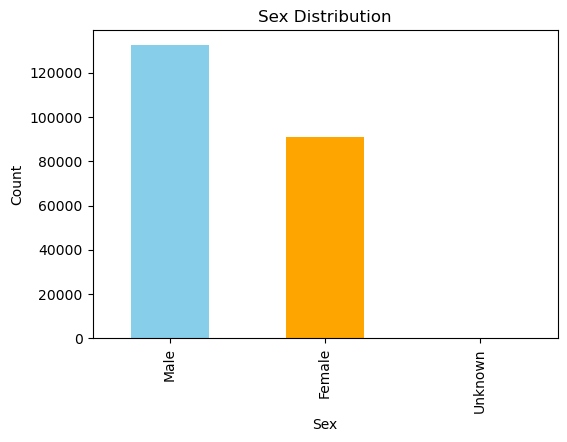

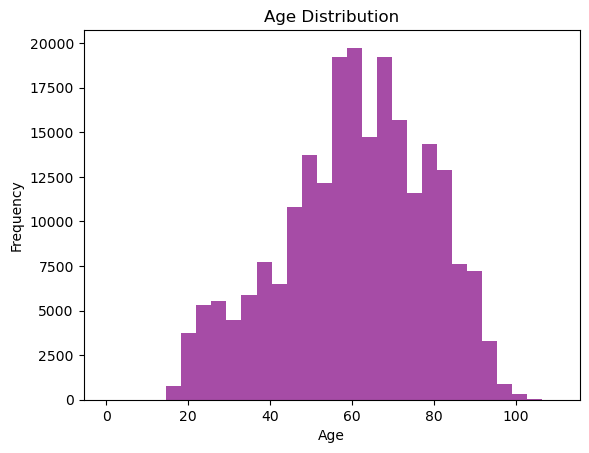

In [16]:
# sex distribution
print("Sex Distribution:")
print(train_df["Sex"].value_counts())

# plot sex distribution
train_df["Sex"].value_counts().plot(kind="bar", figsize=(6, 4), color=["skyblue", "orange"])
plt.title("Sex Distribution")
plt.ylabel("Count")
plt.xlabel("Sex")
plt.show()

# age distribution
plt.hist(train_df["Age"].dropna(), bins=30, alpha=0.7, color="purple")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

Sex Distribution:
Sex
Male      92854
Female    68736
Name: count, dtype: int64


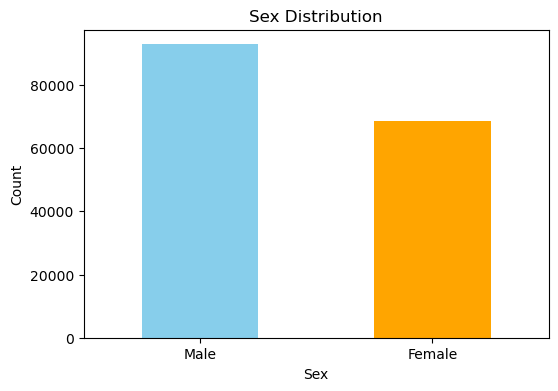

Age Distribution:
Age
61     3865
66     3728
58     3640
64     3637
65     3612
       ... 
108       3
0         3
107       2
109       1
105       1
Name: count, Length: 94, dtype: int64


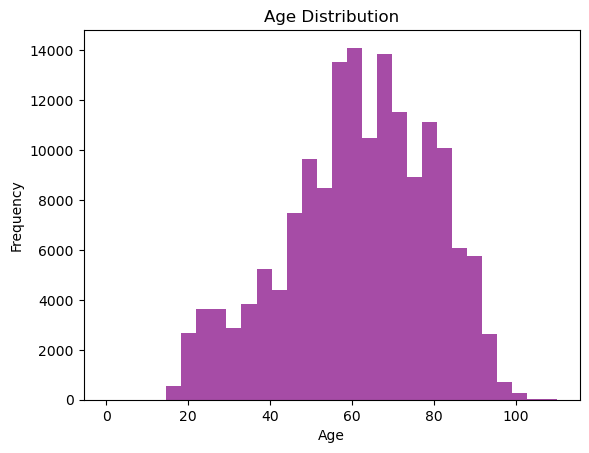

In [17]:
# sex distribution for the subset of training data
print("Sex Distribution:")
print(sub_train_df["Sex"].value_counts())

sub_train_df["Sex"].value_counts().plot(kind="bar", figsize=(6, 4), color=["skyblue", "orange"])
plt.title("Sex Distribution")
plt.ylabel("Count")
plt.xlabel("Sex")
plt.xticks(rotation=0)
plt.show()

# age distribution for the subset of training data
print("Age Distribution:")
print(sub_train_df["Age"].value_counts())

plt.hist(sub_train_df["Age"].dropna(), bins=30, alpha=0.7, color="purple")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

Frontal/Lateral Distribution:
Frontal/Lateral
Frontal    191027
Lateral     32387
Name: count, dtype: int64


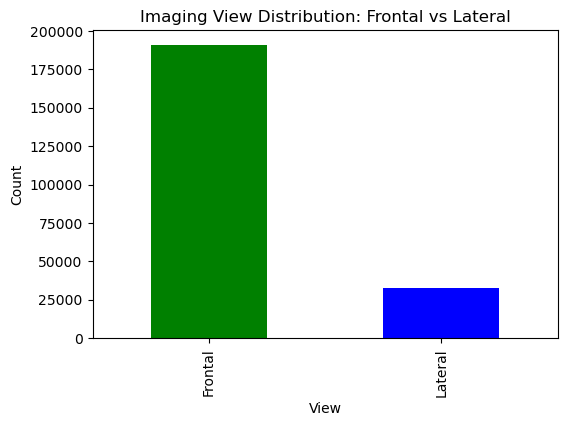

AP/PA Distribution:
AP/PA
AP    161590
PA     29420
LL        16
RL         1
Name: count, dtype: int64


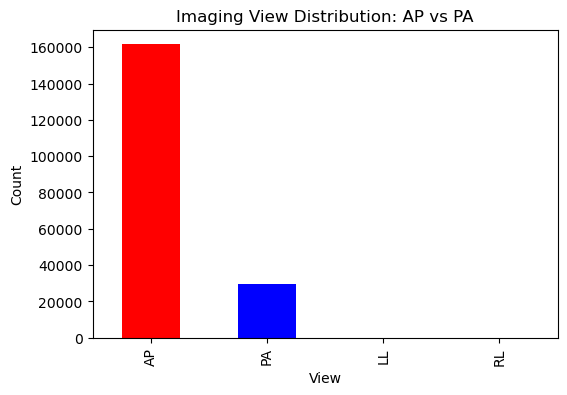

In [18]:
# frontal/lateral distribution
print("Frontal/Lateral Distribution:")
print(train_df["Frontal/Lateral"].value_counts())

# plot frontal/lateral distribution
train_df["Frontal/Lateral"].value_counts().plot(kind="bar", figsize=(6, 4), color=["green", "blue"])
plt.title("Imaging View Distribution: Frontal vs Lateral")
plt.ylabel("Count")
plt.xlabel("View")
plt.show()

# AP/PA distribution
print("AP/PA Distribution:")
print(train_df["AP/PA"].value_counts())

# plot AP/PA distribution
train_df["AP/PA"].value_counts().plot(kind="bar", figsize=(6, 4), color=["red", "blue"])
plt.title("Imaging View Distribution: AP vs PA")
plt.ylabel("Count")
plt.xlabel("View")
plt.show()

In [19]:
# front/lateral distribution for the subset of training data
print("Frontal/Lateral Distribution:")
print(sub_train_df["Frontal/Lateral"].value_counts())

# ap/pa distribution for the subset of training data
print("AP/PA Distribution:")    
print(sub_train_df["AP/PA"].value_counts())

Frontal/Lateral Distribution:
Frontal/Lateral
Frontal    161590
Name: count, dtype: int64
AP/PA Distribution:
AP/PA
AP    161590
Name: count, dtype: int64
